In [1]:
import sys
sys.path.insert(0, '..')

# =====================================================
# EXPLORATORY ANALYSIS: METRICS OVER TIME
# =====================================================
# This notebook analyzes how metrics changes over time
# for different player types, with 95% confidence intervals.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Import utility functions from plot_utilities
from plot_utilities import (
    load_turn_data,
    setup_notebook_display,
    plot_metric_over_time  # Generalized function for any metric
)

# Set up notebook display and plotting style
setup_notebook_display(figsize=(12, 6))

# Load turn data with player type mapping automatically applied
turn_df = load_turn_data('../turn_data.csv', condition_exclude=["observe-vanilla-standard"])

d:\Cache\Onedrive - Arizona\OneDrive - University of Arizona\Vox Deorum\nlp-2026-tiny-4player\analysis\exploratory\..\plot_utilities.py:401: DtypeWarning: Columns (63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✓ Loaded turn data: 757328 rows
✓ Filters applied: condition_exclude=['observe-vanilla-standard']
✓ Unique conditions: 11
✓ Unique player types: 13
✓ Turn range: 0 - 500
✓ Unique civilizations: 43

Player Type Distribution:
  Vanilla: 259866 rows (34.3%)
  GLM-4.7-Simple: 74906 rows (9.9%)
  GLM-4.7-Briefed: 74906 rows (9.9%)
  Kimi-K2.5-Briefed: 50813 rows (6.7%)
  Kimi-K2.5-Simple: 50813 rows (6.7%)
  GPT-OSS-120B-Briefed: 49211 rows (6.5%)
  GPT-OSS-120B-Simple: 49211 rows (6.5%)
  Deepseek-3.2-Simple: 47818 rows (6.3%)
  Deepseek-3.2-Briefed: 47818 rows (6.3%)
  Minimax-M2.5-Briefed: 14791 rows (2.0%)
  Minimax-M2.5-Simple: 14791 rows (2.0%)
  Sonnet-4.5-Briefed: 11192 rows (1.5%)
  Sonnet-4.5-Simple: 11192 rows (1.5%)

Condition Distribution:
  2026-deepseek-v-kimi2-v-glm-standard: 281688 rows (37.2%)
  2026-oss-v-glm-standard: 223776 rows (29.5%)
  2026-deepseek-v-kimi2-v-minimax-standard: 56856 rows (7.5%)
  2026-oss-v-sonnet-standard: 45584 rows (6.0%)
  2026-oss-v-minimax-stan

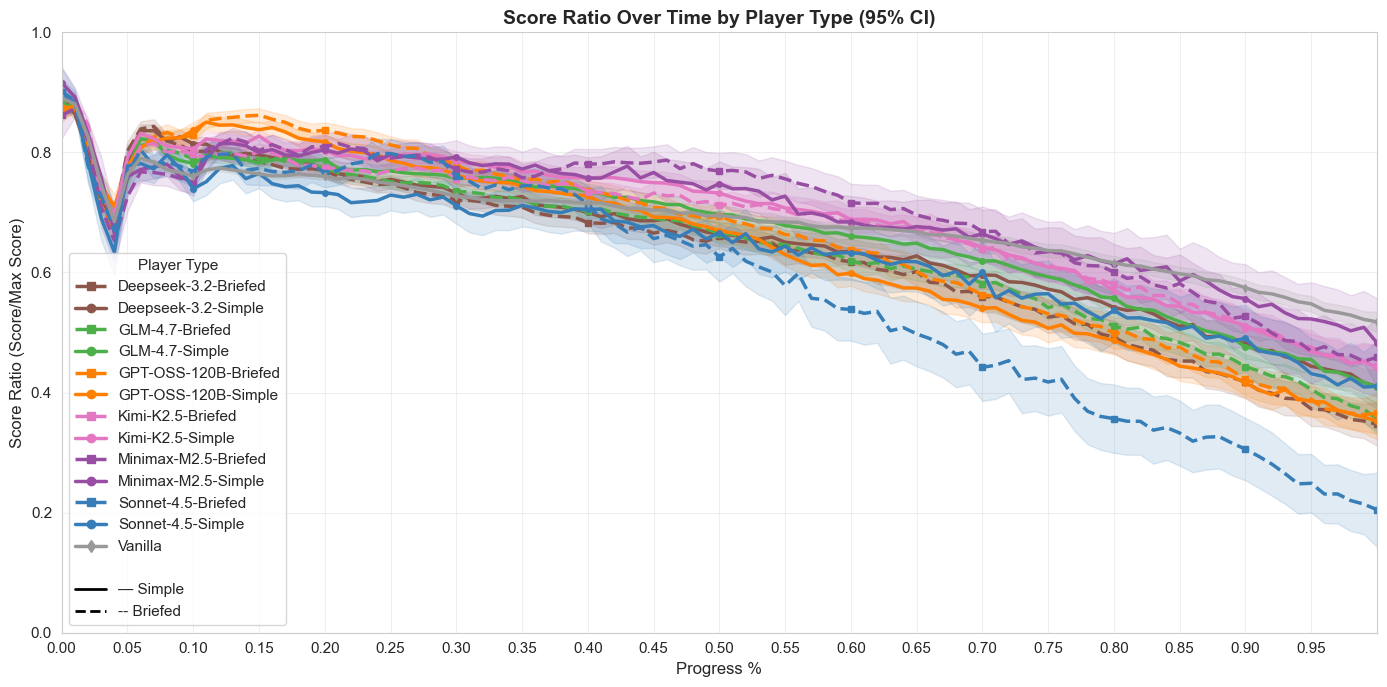

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,47818,0.630,0.274,0.0,1.0,-0.462959,-0.490
Deepseek-3.2-Simple,47818,0.655,0.257,0.0,1.0,-0.389192,-0.439
GLM-4.7-Briefed,74906,0.642,0.261,0.0,1.0,-0.429913,-0.476
GLM-4.7-Simple,74906,0.669,0.238,0.0,1.0,-0.381921,-0.464
GPT-OSS-120B-Briefed,49211,0.657,0.277,0.0,1.0,-0.503243,-0.524
GPT-OSS-120B-Simple,49211,0.640,0.266,0.0,1.0,-0.512871,-0.557
Kimi-K2.5-Briefed,50813,0.684,0.251,0.0,1.0,-0.345194,-0.398
Kimi-K2.5-Simple,50813,0.694,0.265,0.0,1.0,-0.373168,-0.407
Minimax-M2.5-Briefed,14791,0.704,0.236,0.0,1.0,-0.322510,-0.395
Minimax-M2.5-Simple,14791,0.705,0.267,0.0,1.0,-0.301064,-0.326


In [2]:
# Plot score ratio over time using the generalized plot_metric_over_time function
# This calculates score_ratio as score/max_score dynamically
fig, ax = plot_metric_over_time(
    turn_df,
    metric_calculation=lambda df: df['score'] / df['max_score'],
    title="Score Ratio Over Time by Player Type",
    ylabel="Score Ratio (Score/Max Score)",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, 1)  # Score ratio is always between 0 and 1
)

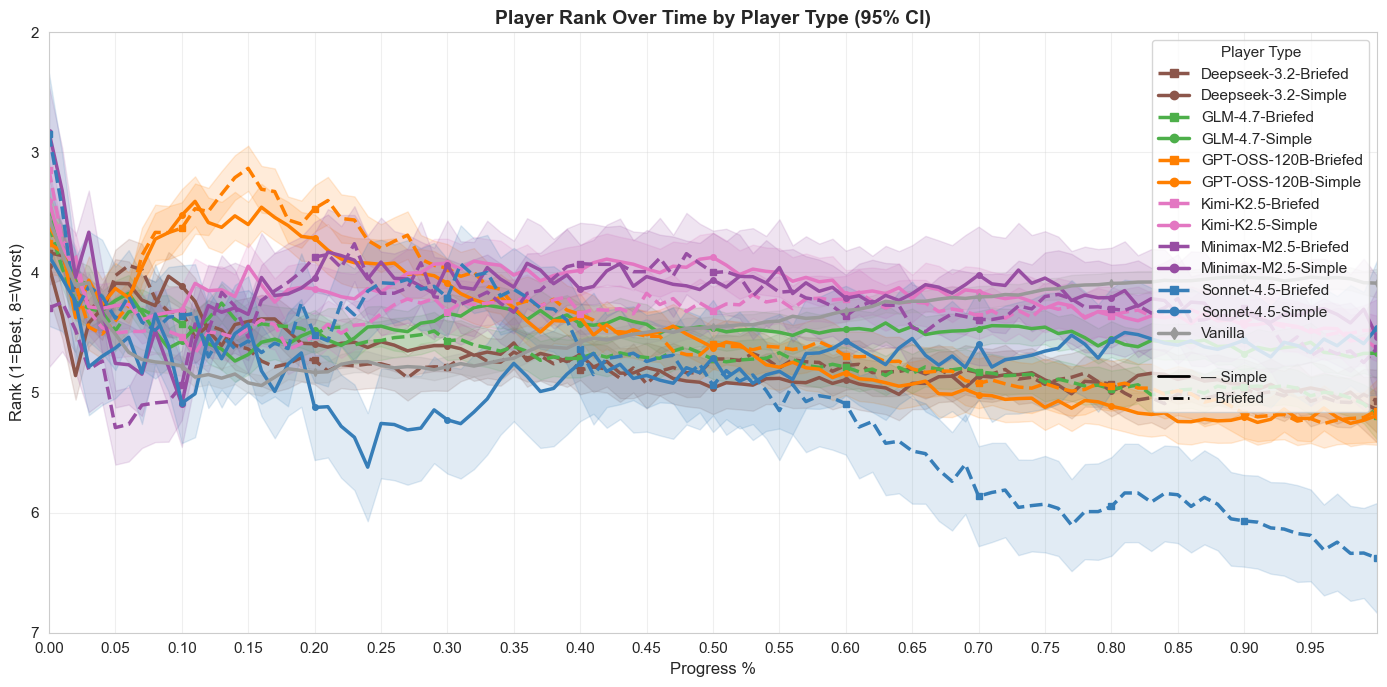

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,47818,4.756,2.279,1,8,0.712430,0.090
Deepseek-3.2-Simple,47818,4.745,2.338,1,8,0.730156,0.090
GLM-4.7-Briefed,74906,4.698,2.247,1,8,0.787688,0.101
GLM-4.7-Simple,74906,4.476,2.223,1,8,0.280895,0.037
GPT-OSS-120B-Briefed,49211,4.451,2.384,1,8,1.807291,0.219
GPT-OSS-120B-Simple,49211,4.550,2.257,1,8,1.828037,0.234
Kimi-K2.5-Briefed,50813,4.333,2.268,1,8,0.045332,0.006
Kimi-K2.5-Simple,50813,4.164,2.355,1,8,0.370305,0.046
Minimax-M2.5-Briefed,14791,4.298,2.191,1,8,0.003856,0.001
Minimax-M2.5-Simple,14791,4.171,2.416,1,8,0.121024,0.014


In [3]:
# Create the rank over time plot with 95% confidence intervals
# Using the generalized plot_metric_over_time function
# Note: Lower rank is better (1 = first place, 4 = last place)
# We invert the y-axis to show better performance at the top
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='rank',  # Use the 'rank' column directly
    title="Player Rank Over Time by Player Type",
    ylabel="Rank (1=Best, 8=Worst)",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(2, 7),   # Set y-axis limits for rank (1-8 with padding)
    invert_y=True,     # Invert y-axis so lower (better) rank appears higher
    legend_loc='upper right'
)

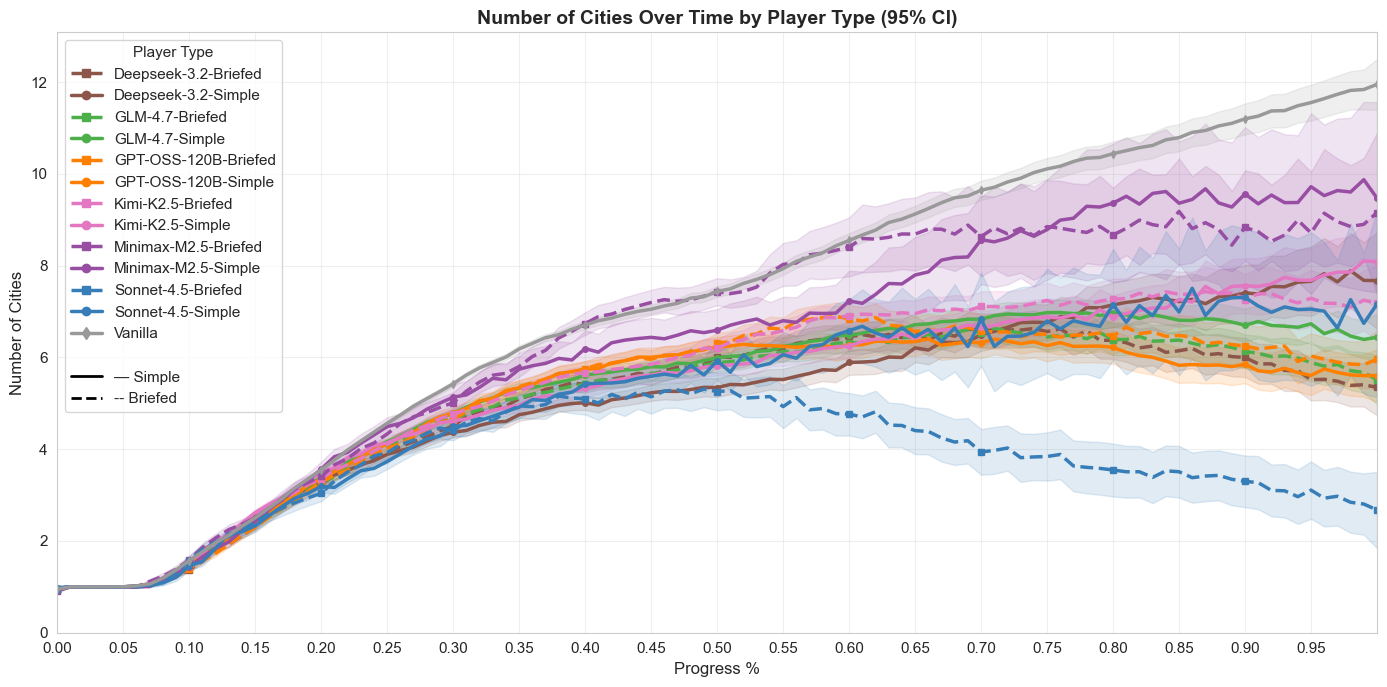

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,47818,4.904,3.664,0,25,5.188880,0.410
Deepseek-3.2-Simple,47818,5.075,4.415,0,49,6.775956,0.444
GLM-4.7-Briefed,74906,4.951,3.766,0,41,5.308155,0.408
GLM-4.7-Simple,74906,5.209,3.609,0,31,5.998494,0.481
GPT-OSS-120B-Briefed,49211,5.118,3.824,0,24,5.461542,0.412
GPT-OSS-120B-Simple,49211,4.958,3.485,0,26,4.815109,0.399
Kimi-K2.5-Briefed,50813,5.419,4.134,0,39,6.700375,0.469
Kimi-K2.5-Simple,50813,5.272,4.435,0,58,6.763786,0.441
Minimax-M2.5-Briefed,14791,6.406,5.201,0,33,8.784670,0.489
Minimax-M2.5-Simple,14791,6.257,5.826,0,43,9.341840,0.464


In [4]:
# Plot number of cities over time using the generalized plot_metric_over_time function
# Cities are a key indicator of expansion and empire building in Civilization
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='cities',  # Use the 'cities' column directly
    title="Number of Cities Over Time by Player Type",
    ylabel="Number of Cities",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    use_turn_progress=True,
    print_summary=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Cities generally increase over time
)

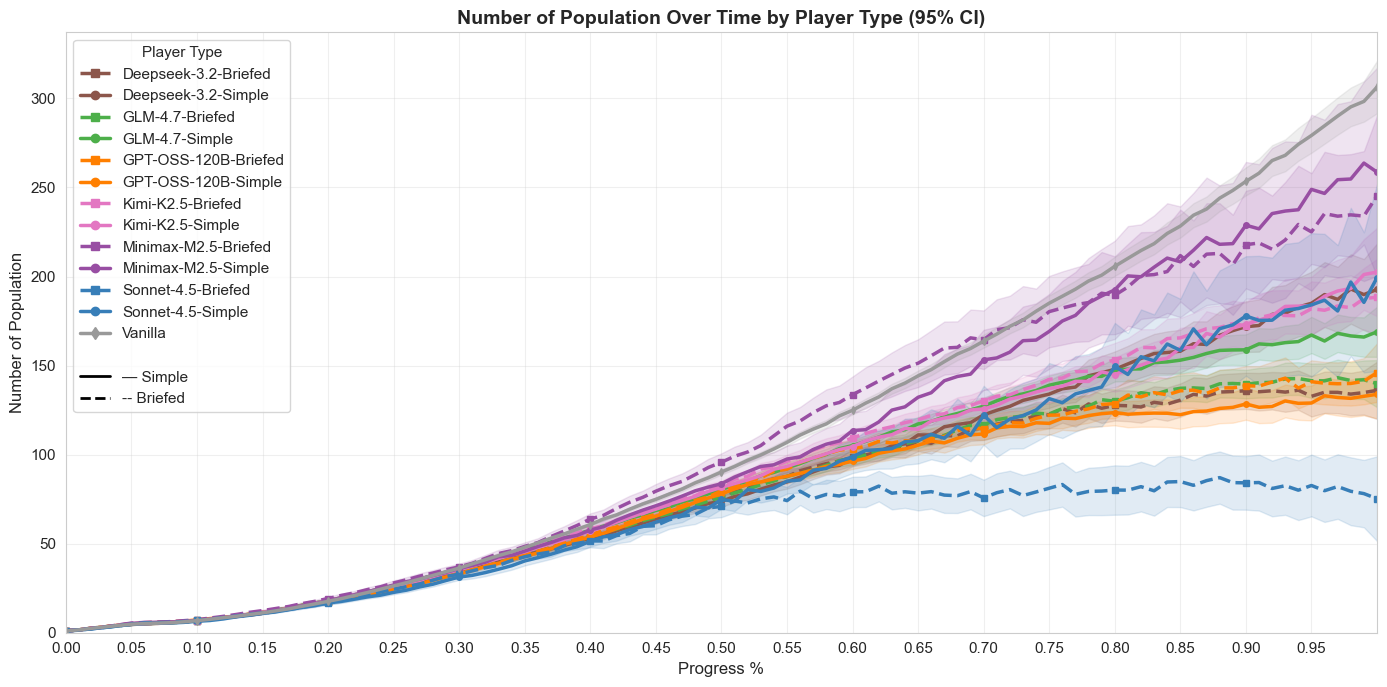

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,47818,73.295,80.327,0,651,163.896746,0.590
Deepseek-3.2-Simple,47818,82.264,103.872,0,1122,207.078905,0.577
GLM-4.7-Briefed,74906,74.916,80.992,0,965,170.290850,0.608
GLM-4.7-Simple,74906,82.619,86.445,0,785,194.987564,0.652
GPT-OSS-120B-Briefed,49211,75.583,82.880,0,764,168.657462,0.587
GPT-OSS-120B-Simple,49211,72.052,73.114,0,603,156.835701,0.619
Kimi-K2.5-Briefed,50813,86.256,99.780,0,898,210.925313,0.612
Kimi-K2.5-Simple,50813,84.967,103.398,0,1322,209.365428,0.586
Minimax-M2.5-Briefed,14791,105.361,124.949,0,909,269.607454,0.624
Minimax-M2.5-Simple,14791,101.776,140.395,0,1277,276.307451,0.569


In [5]:
# Plot number of population over time using the generalized plot_metric_over_time function
# Cities are a key indicator of expansion and empire building in Civilization
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='population',  # Use the 'population' column directly
    title="Number of Population Over Time by Player Type",
    ylabel="Number of Population",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    use_turn_progress=True,
    print_summary=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Population generally increase over time
)

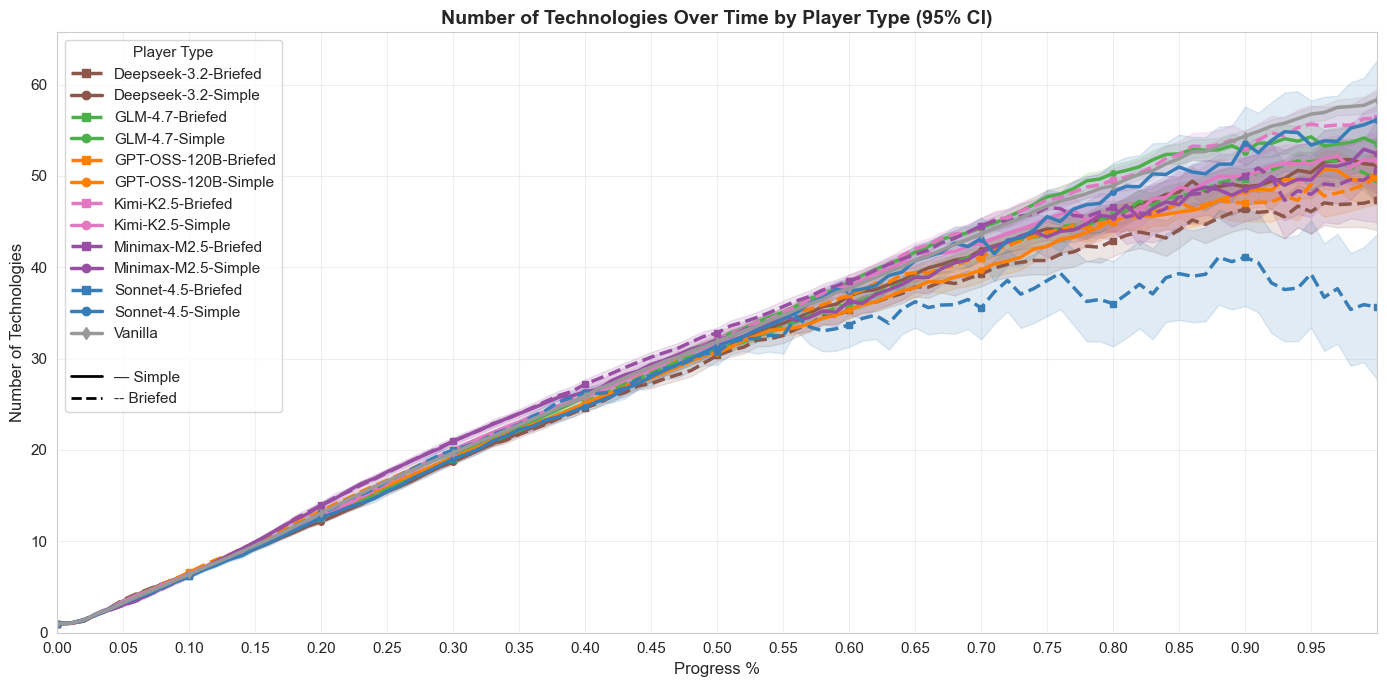

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,47818,28.001,19.563,0,82,49.076753,0.726
Deepseek-3.2-Simple,47818,29.321,19.475,0,82,54.156787,0.805
GLM-4.7-Briefed,74906,29.453,19.843,0,82,53.955503,0.786
GLM-4.7-Simple,74906,31.110,19.983,0,82,58.792976,0.851
GPT-OSS-120B-Briefed,49211,29.523,19.268,0,82,51.137645,0.766
GPT-OSS-120B-Simple,49211,28.976,19.299,0,82,51.805939,0.775
Kimi-K2.5-Briefed,50813,31.232,20.413,0,82,59.362954,0.842
Kimi-K2.5-Simple,50813,30.084,20.127,0,82,54.577610,0.785
Minimax-M2.5-Briefed,14791,30.441,19.074,0,82,52.948567,0.803
Minimax-M2.5-Simple,14791,29.829,19.104,0,82,52.454856,0.794


In [6]:
# Plot number of technologies over time using the generalized plot_metric_over_time function
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='technologies',  # Use the 'technologies' column directly
    title="Number of Technologies Over Time by Player Type",
    ylabel="Number of Technologies",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Technology generally increase over time
)

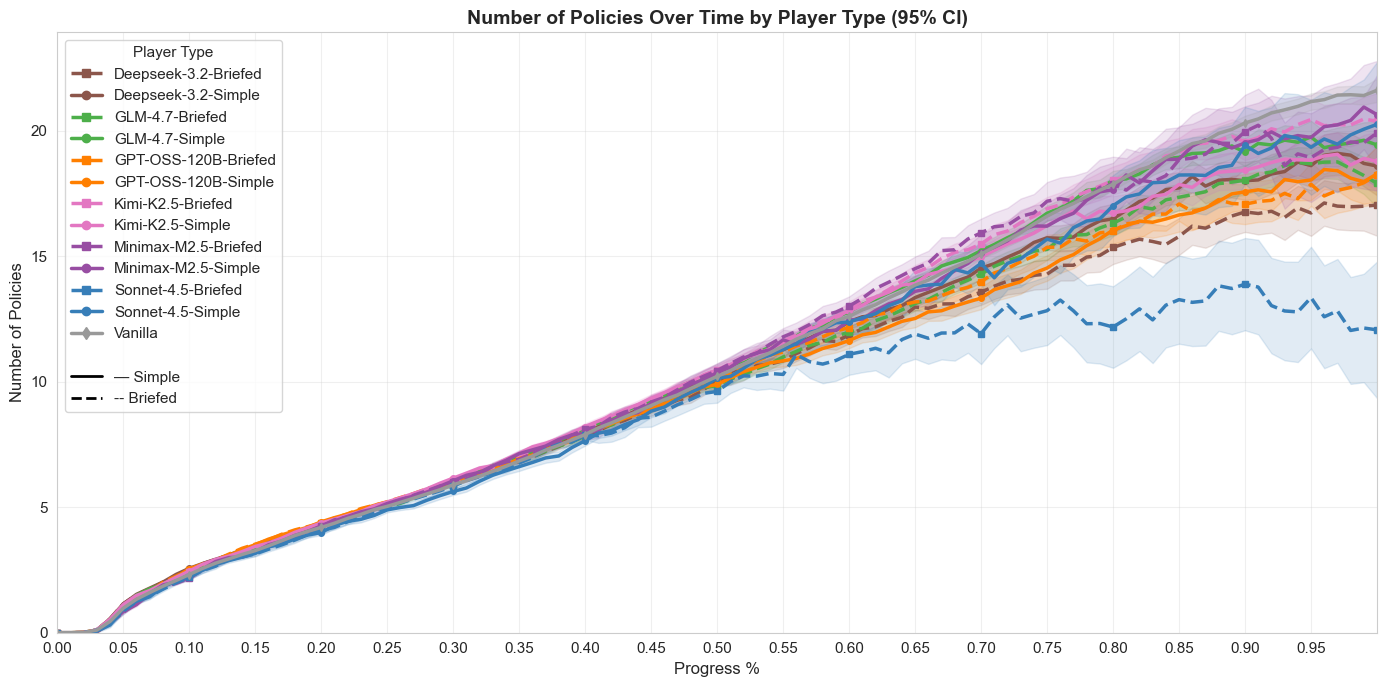

,N,Mean,Std,Min,Max,Slope,r
Deepseek-3.2-Briefed,47818,9.621,7.216,0,33,17.927236,0.719
Deepseek-3.2-Simple,47818,10.222,7.321,0,34,19.991371,0.790
GLM-4.7-Briefed,74906,10.068,7.330,0,33,19.801298,0.781
GLM-4.7-Simple,74906,10.669,7.410,0,35,21.505313,0.839
GPT-OSS-120B-Briefed,49211,10.012,7.218,0,38,18.893897,0.756
GPT-OSS-120B-Simple,49211,9.881,7.043,0,35,18.871808,0.774
Kimi-K2.5-Briefed,50813,10.771,7.787,0,36,22.100950,0.821
Kimi-K2.5-Simple,50813,10.427,7.584,0,35,20.388301,0.778
Minimax-M2.5-Briefed,14791,10.682,7.906,0,38,21.722910,0.795
Minimax-M2.5-Simple,14791,10.595,7.864,0,32,21.789272,0.801


In [7]:
# Plot number of policies over time using the generalized plot_metric_over_time function
fig, ax = plot_metric_over_time(
    turn_df,
    metric_col='policies',  # Use the 'policies' column directly
    title="Number of Policies Over Time by Player Type",
    ylabel="Number of Policies",
    figsize=(14, 7),
    show_confidence=True,
    confidence_level=0.95,
    print_summary=True,
    use_turn_progress=True,
    ylim=(0, None),    # Start at 0, let max adjust automatically
    legend_loc='upper left'  # Technology generally increase over time
)